In [2]:

from pathlib import Path
import os
import tarfile
import urllib.request
import gzip
import shutil
import random
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Project folders
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
DATA_ROOT.mkdir(exist_ok=True)
OUTPUT_ROOT.mkdir(exist_ok=True)

# Dataset download
FRAMES_URL = "https://github.com/jchazalon/smartdoc15-ch1-dataset/releases/download/v2.0.0/frames.tar.gz"
ARCHIVE_PATH = DATA_ROOT / "frames.tar.gz"
EXTRACT_DIR = DATA_ROOT / "smartdoc_frames"

# Training controls
IMAGE_SIZE = 256         # 256 is a good compromise for a class project
FRAME_STRIDE = 8         # keeps every 8th frame to reduce near-duplicates
MAX_SAMPLES = 3000       # reduce to 1000 if your laptop is slow
VAL_SIZE = 0.2
BATCH_SIZE = 8 if torch.cuda.is_available() else 4
EPOCHS = 5               # raise to 8-10 if training is fast
LEARNING_RATE = 1e-3
THRESHOLD = 0.5

Using device: cpu


In [3]:

from pathlib import Path
import os
import tarfile
import urllib.request
import gzip
import shutil
import random
from dataclasses import dataclass

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# Project folders
PROJECT_ROOT = Path.cwd()
DATA_ROOT = PROJECT_ROOT / "data"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
DATA_ROOT.mkdir(exist_ok=True)
OUTPUT_ROOT.mkdir(exist_ok=True)

# Dataset download
FRAMES_URL = "https://github.com/jchazalon/smartdoc15-ch1-dataset/releases/download/v2.0.0/frames.tar.gz"
ARCHIVE_PATH = DATA_ROOT / "frames.tar.gz"
EXTRACT_DIR = DATA_ROOT / "smartdoc_frames"

# Training controls
IMAGE_SIZE = 256         # 256 is a good compromise for a class project
FRAME_STRIDE = 8         # keeps every 8th frame to reduce near-duplicates
MAX_SAMPLES = 3000       # reduce to 1000 if your laptop is slow
VAL_SIZE = 0.2
BATCH_SIZE = 8 if torch.cuda.is_available() else 4
EPOCHS = 5               # raise to 8-10 if training is fast
LEARNING_RATE = 1e-3
THRESHOLD = 0.5

Using device: cpu


In [4]:

def download_file(url: str, dest: Path):
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists():
        print(f"Archive already exists: {dest}")
        return
    print(f"Downloading to {dest} ...")
    urllib.request.urlretrieve(url, dest)
    print("Download complete.")

def extract_tar_gz(archive_path: Path, extract_dir: Path):
    extract_dir.mkdir(parents=True, exist_ok=True)
    marker = extract_dir / ".extracted_ok"
    if marker.exists():
        print(f"Archive already extracted: {extract_dir}")
        return
    print(f"Extracting {archive_path} ... this may take a few minutes.")
    with tarfile.open(archive_path, "r:gz") as tar:
        tar.extractall(path=extract_dir)
    marker.write_text("done", encoding="utf-8")
    print("Extraction complete.")

download_file(FRAMES_URL, ARCHIVE_PATH)
extract_tar_gz(ARCHIVE_PATH, EXTRACT_DIR)

Download complete.
Extracting /Users/dinura.dissanayake/Desktop/document_scanner_project/data/frames.tar.gz ... this may take a few minutes.
Extraction complete.


In [5]:

def find_metadata_file(root: Path) -> Path:
    candidates = list(root.rglob("metadata.csv.gz")) + list(root.rglob("metadata.csv"))
    if not candidates:
        raise FileNotFoundError("Could not find metadata.csv.gz or metadata.csv after extraction.")
    return candidates[0]

METADATA_PATH = find_metadata_file(EXTRACT_DIR)
print("Metadata file:", METADATA_PATH)

if METADATA_PATH.suffix == ".gz":
    metadata = pd.read_csv(METADATA_PATH, compression="gzip")
else:
    metadata = pd.read_csv(METADATA_PATH)

print("Rows:", len(metadata))
display(metadata.head())

Metadata file: /Users/dinura.dissanayake/Desktop/document_scanner_project/data/smartdoc_frames/metadata.csv.gz
Rows: 24889


,bg_name,bg_id,model_name,model_id,modeltype_name,modeltype_id,model_subid,image_path,frame_index,model_width,model_height,tl_x,tl_y,bl_x,bl_y,br_x,br_y,tr_x,tr_y
0,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0001.jpeg,1,2100.0,2970.0,698.087,200.476,692.141,891.077,1253.18,869.656,1178.15,191.515
1,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0002.jpeg,2,2100.0,2970.0,697.230,197.947,690.063,893.292,1254.61,871.689,1179.66,188.863
2,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0003.jpeg,3,2100.0,2970.0,694.344,197.669,693.706,885.112,1243.87,864.328,1176.90,188.845
3,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0004.jpeg,4,2100.0,2970.0,698.721,205.968,691.818,883.776,1240.73,862.179,1168.99,197.357
4,background01,0,datasheet001,0,datasheet,0,0,background01/datasheet001/frame_0005.jpeg,5,2100.0,2970.0,696.853,205.898,690.721,883.791,1240.38,862.077,1167.82,196.579


In [6]:

# Keep every nth frame to reduce near-duplicate images
metadata_sub = metadata[(metadata["frame_index"] - 1) % FRAME_STRIDE == 0].copy()

# Group by video/session so train-val split is less leaky
metadata_sub["session_id"] = metadata_sub["bg_name"].astype(str) + "_" + metadata_sub["model_name"].astype(str)

if len(metadata_sub) > MAX_SAMPLES:
    metadata_sub = metadata_sub.sample(n=MAX_SAMPLES, random_state=SEED).reset_index(drop=True)
else:
    metadata_sub = metadata_sub.reset_index(drop=True)

print("Subsampled rows:", len(metadata_sub))
print("Unique sessions:", metadata_sub["session_id"].nunique())

splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(metadata_sub, groups=metadata_sub["session_id"]))

train_df = metadata_sub.iloc[train_idx].reset_index(drop=True)
val_df = metadata_sub.iloc[val_idx].reset_index(drop=True)

print("Train size:", len(train_df))
print("Val size:", len(val_df))

Subsampled rows: 3000
Unique sessions: 150
Train size: 2406
Val size: 594


In [7]:

def read_rgb_image(image_path: Path):
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")
    image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    return image_rgb

def get_quad_from_row(row):
    return np.array([
        [row["tl_x"], row["tl_y"]],
        [row["bl_x"], row["bl_y"]],
        [row["br_x"], row["br_y"]],
        [row["tr_x"], row["tr_y"]],
    ], dtype=np.float32)

def resize_quad(quad, orig_w, orig_h, target_w, target_h):
    sx = target_w / orig_w
    sy = target_h / orig_h
    quad_resized = quad.copy()
    quad_resized[:, 0] *= sx
    quad_resized[:, 1] *= sy
    return quad_resized

def quad_to_mask(quad, height, width):
    mask = np.zeros((height, width), dtype=np.uint8)
    pts = np.round(quad).astype(np.int32)
    cv2.fillConvexPoly(mask, pts, 255)
    return mask

def show_image_and_mask(image, mask, title_image="Image", title_mask="Mask"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(image)
    axes[0].set_title(title_image)
    axes[0].axis("off")
    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(title_mask)
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()

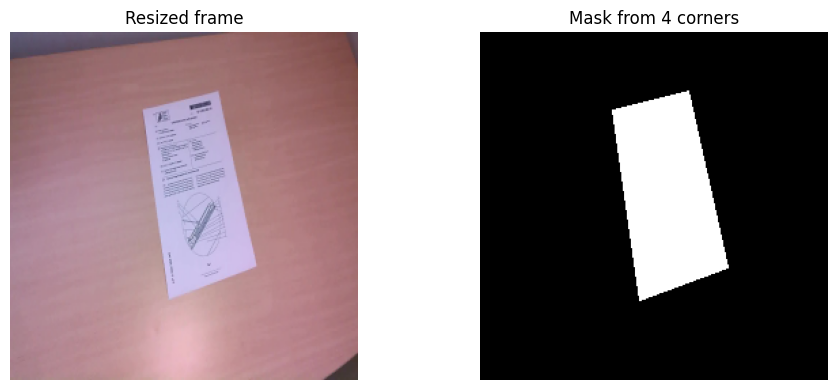

In [8]:

sample_row = train_df.sample(1, random_state=SEED).iloc[0]
sample_img_path = EXTRACT_DIR / sample_row["image_path"]
sample_image = read_rgb_image(sample_img_path)
h, w = sample_image.shape[:2]
sample_quad = get_quad_from_row(sample_row)
sample_quad_256 = resize_quad(sample_quad, w, h, IMAGE_SIZE, IMAGE_SIZE)
sample_image_256 = cv2.resize(sample_image, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
sample_mask_256 = quad_to_mask(sample_quad_256, IMAGE_SIZE, IMAGE_SIZE)

show_image_and_mask(sample_image_256, sample_mask_256, "Resized frame", "Mask from 4 corners")

In [9]:

class SmartDocSegmentationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, root_dir: Path, image_size: int = 256):
        self.df = df.reset_index(drop=True)
        self.root_dir = root_dir
        self.image_size = image_size

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.root_dir / row["image_path"]

        image = read_rgb_image(image_path)
        orig_h, orig_w = image.shape[:2]

        quad = get_quad_from_row(row)
        quad_resized = resize_quad(quad, orig_w, orig_h, self.image_size, self.image_size)

        image_resized = cv2.resize(image, (self.image_size, self.image_size), interpolation=cv2.INTER_AREA)
        mask = quad_to_mask(quad_resized, self.image_size, self.image_size)

        image_tensor = torch.from_numpy(image_resized).float().permute(2, 0, 1) / 255.0
        mask_tensor = torch.from_numpy(mask).float().unsqueeze(0) / 255.0

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "image_path": str(image_path),
            "orig_size": (orig_h, orig_w),
        }

train_dataset = SmartDocSegmentationDataset(train_df, EXTRACT_DIR, IMAGE_SIZE)
val_dataset = SmartDocSegmentationDataset(val_df, EXTRACT_DIR, IMAGE_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print("Image batch shape:", batch["image"].shape)
print("Mask batch shape:", batch["mask"].shape)

Image batch shape: torch.Size([4, 3, 256, 256])
Mask batch shape: torch.Size([4, 1, 256, 256])


In [10]:

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class TinyUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=(16, 32, 64)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        ch = in_channels
        for feat in features:
            self.downs.append(DoubleConv(ch, feat))
            ch = feat

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        rev_features = list(features[::-1])
        up_ch = features[-1] * 2
        for feat in rev_features:
            self.ups.append(nn.ConvTranspose2d(up_ch, feat, kernel_size=2, stride=2))
            self.ups.append(DoubleConv(up_ch, feat))
            up_ch = feat

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skips = []
        for down in self.downs:
            x = down(x)
            skips.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skips = skips[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)
            skip = skips[idx // 2]

            if x.shape[-2:] != skip.shape[-2:]:
                x = nn.functional.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)

            x = torch.cat([skip, x], dim=1)
            x = self.ups[idx + 1](x)

        return self.final_conv(x)

model = TinyUNet().to(DEVICE)
print(model.__class__.__name__)

TinyUNet


In [11]:

bce_loss = nn.BCEWithLogitsLoss()

def dice_loss(logits, targets, eps=1e-6):
    probs = torch.sigmoid(logits)
    num = 2 * (probs * targets).sum(dim=(1,2,3))
    den = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + eps
    return 1 - (num / den).mean()

def combined_loss(logits, targets):
    return bce_loss(logits, targets) + dice_loss(logits, targets)

def batch_iou(logits, targets, threshold=0.5, eps=1e-6):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    inter = (preds * targets).sum(dim=(1,2,3))
    union = ((preds + targets) > 0).float().sum(dim=(1,2,3))
    return ((inter + eps) / (union + eps)).mean().item()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [12]:

best_val_iou = -1.0
history = {"train_loss": [], "val_loss": [], "train_iou": [], "val_iou": []}
BEST_MODEL_PATH = OUTPUT_ROOT / "best_tiny_unet.pth"

for epoch in range(EPOCHS):
    model.train()
    train_losses, train_ious = [], []

    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - train"):
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)

        optimizer.zero_grad()
        logits = model(images)
        loss = combined_loss(logits, masks)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_ious.append(batch_iou(logits.detach(), masks))

    model.eval()
    val_losses, val_ious = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{EPOCHS} - val"):
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)

            logits = model(images)
            loss = combined_loss(logits, masks)

            val_losses.append(loss.item())
            val_ious.append(batch_iou(logits, masks))

    epoch_train_loss = float(np.mean(train_losses))
    epoch_val_loss = float(np.mean(val_losses))
    epoch_train_iou = float(np.mean(train_ious))
    epoch_val_iou = float(np.mean(val_ious))

    history["train_loss"].append(epoch_train_loss)
    history["val_loss"].append(epoch_val_loss)
    history["train_iou"].append(epoch_train_iou)
    history["val_iou"].append(epoch_val_iou)

    if epoch_val_iou > best_val_iou:
        best_val_iou = epoch_val_iou
        torch.save(model.state_dict(), BEST_MODEL_PATH)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"train_loss={epoch_train_loss:.4f} val_loss={epoch_val_loss:.4f} "
        f"train_iou={epoch_train_iou:.4f} val_iou={epoch_val_iou:.4f}"
    )

print("Best model saved to:", BEST_MODEL_PATH)
print("Best validation IoU:", best_val_iou)

Epoch 1/5 - val: 100%|██████████| 149/149 [00:23<00:00,  6.22it/s]


Epoch 1/5 | train_loss=0.3047 val_loss=0.0689 train_iou=0.9233 val_iou=0.9559


Epoch 2/5 - val: 100%|██████████| 149/149 [00:23<00:00,  6.26it/s]


Epoch 2/5 | train_loss=0.0420 val_loss=0.0440 train_iou=0.9688 val_iou=0.9642


Epoch 3/5 - val: 100%|██████████| 149/149 [00:24<00:00,  6.16it/s]


Epoch 3/5 | train_loss=0.0301 val_loss=0.0272 train_iou=0.9734 val_iou=0.9744


Epoch 4/5 - val: 100%|██████████| 149/149 [00:23<00:00,  6.27it/s]


Epoch 4/5 | train_loss=0.0237 val_loss=0.0886 train_iou=0.9772 val_iou=0.9233


Epoch 5/5 - val: 100%|██████████| 149/149 [00:24<00:00,  6.16it/s]

Epoch 5/5 | train_loss=0.0272 val_loss=0.0265 train_iou=0.9742 val_iou=0.9737
Best model saved to: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs/best_tiny_unet.pth
Best validation IoU: 0.9744292069601532


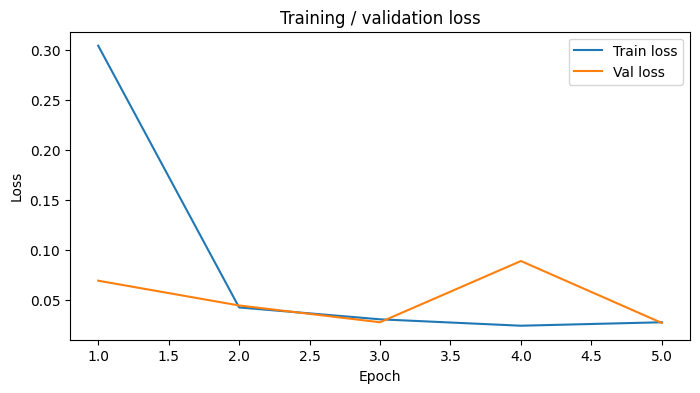

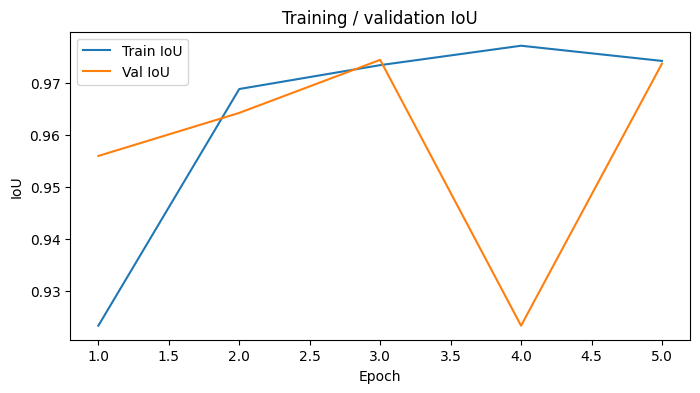

In [13]:

epochs_axis = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history["train_loss"], label="Train loss")
plt.plot(epochs_axis, history["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training / validation loss")
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(epochs_axis, history["train_iou"], label="Train IoU")
plt.plot(epochs_axis, history["val_iou"], label="Val IoU")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.title("Training / validation IoU")
plt.show()

In [14]:

best_model = TinyUNet().to(DEVICE)
best_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
best_model.eval()
print("Best model loaded.")

Best model loaded.


In [15]:

def predict_mask_for_image(model, image_rgb, image_size=256):
    orig_h, orig_w = image_rgb.shape[:2]
    resized = cv2.resize(image_rgb, (image_size, image_size), interpolation=cv2.INTER_AREA)
    tensor = torch.from_numpy(resized).float().permute(2, 0, 1).unsqueeze(0) / 255.0
    tensor = tensor.to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs = torch.sigmoid(logits)[0, 0].cpu().numpy()

    mask_small = (probs > THRESHOLD).astype(np.uint8) * 255
    mask_big = cv2.resize(mask_small, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    return probs, mask_small, mask_big

def largest_contour_from_mask(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    return max(contours, key=cv2.contourArea)

def contour_to_quad(contour):
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.02 * peri, True)

    if len(approx) == 4:
        quad = approx.reshape(4, 2).astype(np.float32)
    else:
        rect = cv2.minAreaRect(contour)
        quad = cv2.boxPoints(rect).astype(np.float32)
    return quad

def order_points(pts):
    pts = np.array(pts, dtype=np.float32)
    s = pts.sum(axis=1)
    d = np.diff(pts, axis=1).reshape(-1)

    top_left = pts[np.argmin(s)]
    bottom_right = pts[np.argmax(s)]
    top_right = pts[np.argmin(d)]
    bottom_left = pts[np.argmax(d)]

    return np.array([top_left, top_right, bottom_right, bottom_left], dtype=np.float32)

def four_point_transform(image, pts):
    rect = order_points(pts)
    tl, tr, br, bl = rect

    width_a = np.linalg.norm(br - bl)
    width_b = np.linalg.norm(tr - tl)
    max_width = int(max(width_a, width_b))

    height_a = np.linalg.norm(tr - br)
    height_b = np.linalg.norm(tl - bl)
    max_height = int(max(height_a, height_b))

    max_width = max(max_width, 1)
    max_height = max(max_height, 1)

    dst = np.array([
        [0, 0],
        [max_width - 1, 0],
        [max_width - 1, max_height - 1],
        [0, max_height - 1]
    ], dtype=np.float32)

    M = cv2.getPerspectiveTransform(rect, dst)
    warped = cv2.warpPerspective(image, M, (max_width, max_height))
    return warped, rect

def scanner_enhance(warped_rgb):
    warped_bgr = cv2.cvtColor(warped_rgb, cv2.COLOR_RGB2BGR)
    gray = cv2.cvtColor(warped_bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    scan = cv2.adaptiveThreshold(
        blur, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        21, 10
    )
    return gray, scan

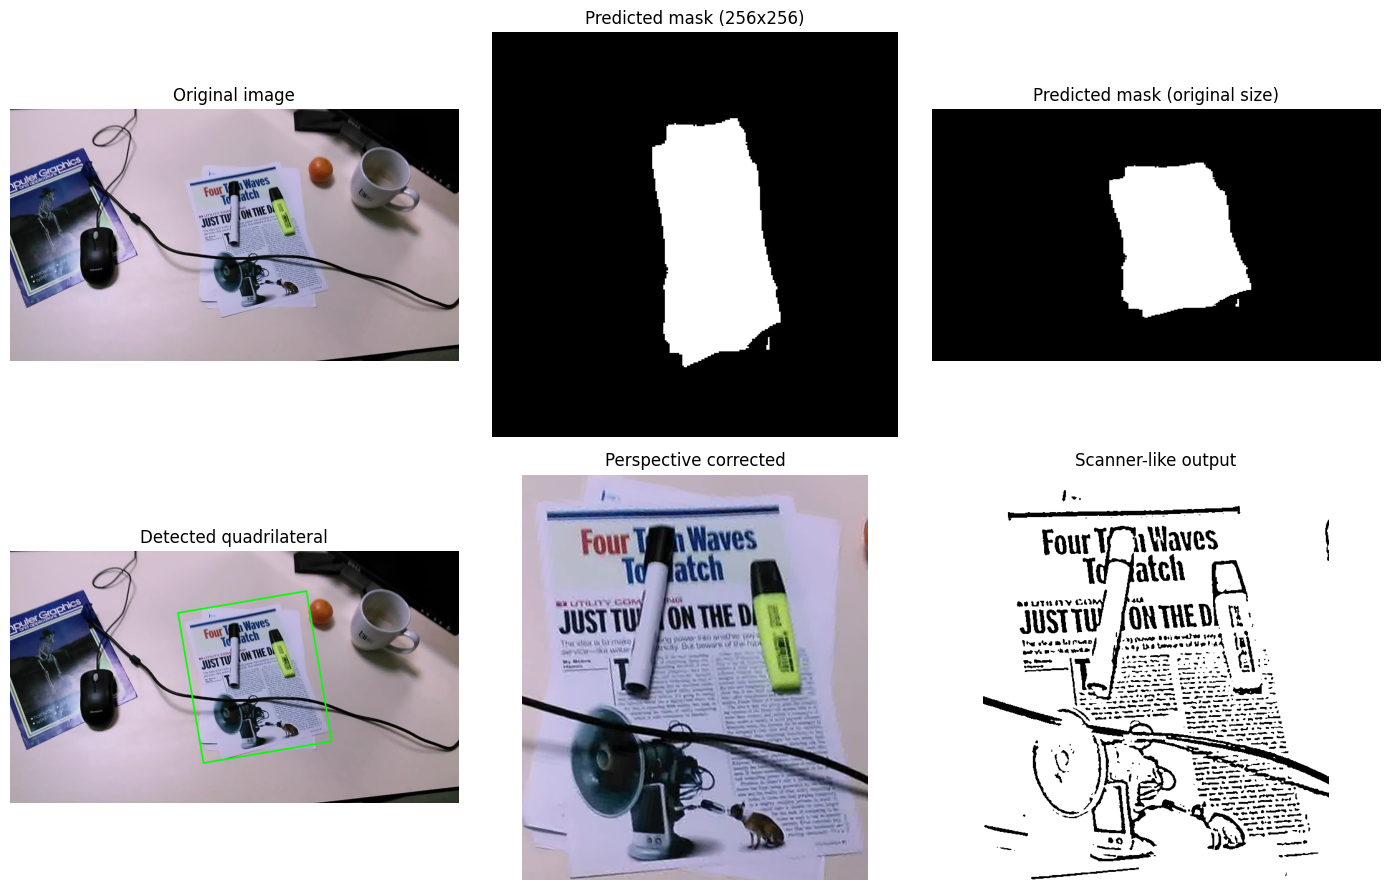

In [16]:

test_row = val_df.sample(1, random_state=SEED).iloc[0]
test_image_path = EXTRACT_DIR / test_row["image_path"]
test_image = read_rgb_image(test_image_path)

probs, mask_small, mask_big = predict_mask_for_image(best_model, test_image, IMAGE_SIZE)
contour = largest_contour_from_mask(mask_big)

if contour is None:
    raise RuntimeError("No document contour found in predicted mask.")

quad = contour_to_quad(contour)
warped, ordered_quad = four_point_transform(test_image, quad)
gray_warped, scan = scanner_enhance(warped)

overlay = test_image.copy()
cv2.polylines(overlay, [ordered_quad.astype(np.int32)], isClosed=True, color=(0, 255, 0), thickness=6)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(test_image)
axes[0, 0].set_title("Original image")
axes[0, 0].axis("off")

axes[0, 1].imshow(mask_small, cmap="gray")
axes[0, 1].set_title("Predicted mask (256x256)")
axes[0, 1].axis("off")

axes[0, 2].imshow(mask_big, cmap="gray")
axes[0, 2].set_title("Predicted mask (original size)")
axes[0, 2].axis("off")

axes[1, 0].imshow(overlay)
axes[1, 0].set_title("Detected quadrilateral")
axes[1, 0].axis("off")

axes[1, 1].imshow(warped)
axes[1, 1].set_title("Perspective corrected")
axes[1, 1].axis("off")

axes[1, 2].imshow(scan, cmap="gray")
axes[1, 2].set_title("Scanner-like output")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

In [17]:

test_name = Path(test_row["image_path"]).stem

overlay_path = OUTPUT_ROOT / f"{test_name}_overlay.jpg"
warped_path = OUTPUT_ROOT / f"{test_name}_warped.jpg"
scan_path = OUTPUT_ROOT / f"{test_name}_scan.jpg"

cv2.imwrite(str(overlay_path), cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(warped_path), cv2.cvtColor(warped, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(scan_path), scan)

print("Saved:")
print(overlay_path)
print(warped_path)
print(scan_path)

Saved:
/Users/dinura.dissanayake/Desktop/document_scanner_project/outputs/frame_0065_overlay.jpg
/Users/dinura.dissanayake/Desktop/document_scanner_project/outputs/frame_0065_warped.jpg
/Users/dinura.dissanayake/Desktop/document_scanner_project/outputs/frame_0065_scan.jpg


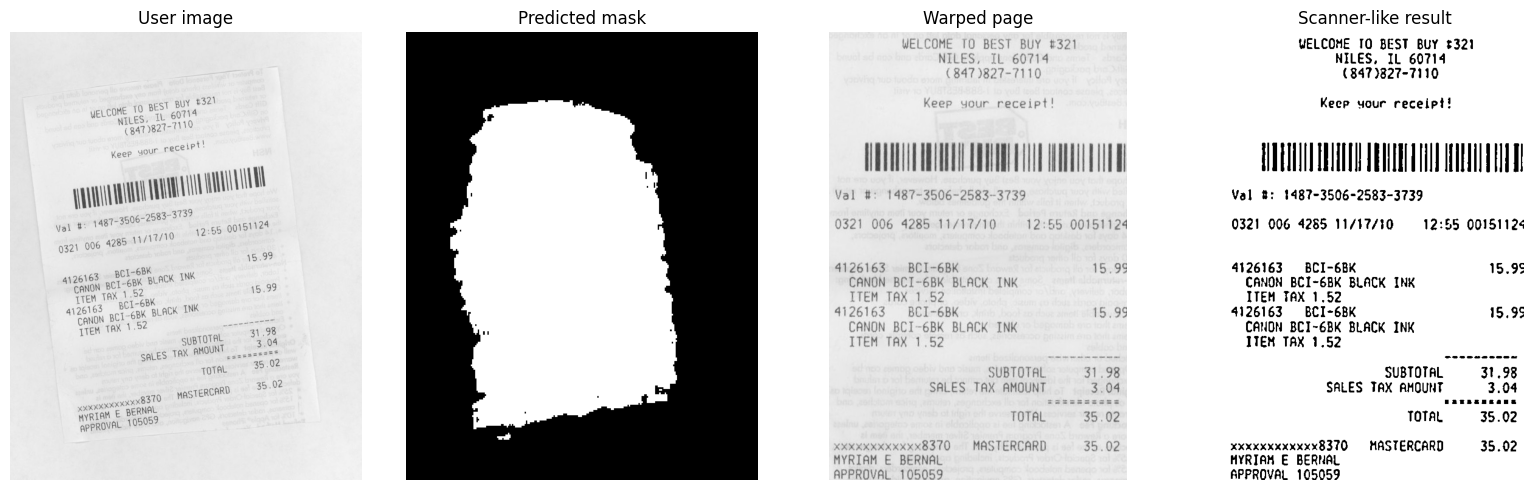

Saved user results inside: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [32]:

USER_IMAGE_PATH = "test.jpg"   # change this
user_path = Path(USER_IMAGE_PATH)

if user_path.exists():
    user_image = read_rgb_image(user_path)
    probs_user, mask_small_user, mask_big_user = predict_mask_for_image(best_model, user_image, IMAGE_SIZE)
    contour_user = largest_contour_from_mask(mask_big_user)

    if contour_user is None:
        raise RuntimeError("No document contour found for the user image.")

    quad_user = contour_to_quad(contour_user)
    warped_user, ordered_quad_user = four_point_transform(user_image, quad_user)
    gray_user, scan_user = scanner_enhance(warped_user)

    user_overlay = user_image.copy()
    cv2.polylines(user_overlay, [ordered_quad_user.astype(np.int32)], isClosed=True, color=(0, 255, 0), thickness=6)

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    axes[0].imshow(user_image)
    axes[0].set_title("User image")
    axes[0].axis("off")

    axes[1].imshow(mask_big_user, cmap="gray")
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")

    axes[2].imshow(warped_user)
    axes[2].set_title("Warped page")
    axes[2].axis("off")

    axes[3].imshow(scan_user, cmap="gray")
    axes[3].set_title("Scanner-like result")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    cv2.imwrite(str(OUTPUT_ROOT / "user_overlay.jpg"), cv2.cvtColor(user_overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_warped.jpg"), cv2.cvtColor(warped_user, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_scan.jpg"), scan_user)

    print("Saved user results inside:", OUTPUT_ROOT)
else:
    print("Set USER_IMAGE_PATH to your own image and rerun this cell.")

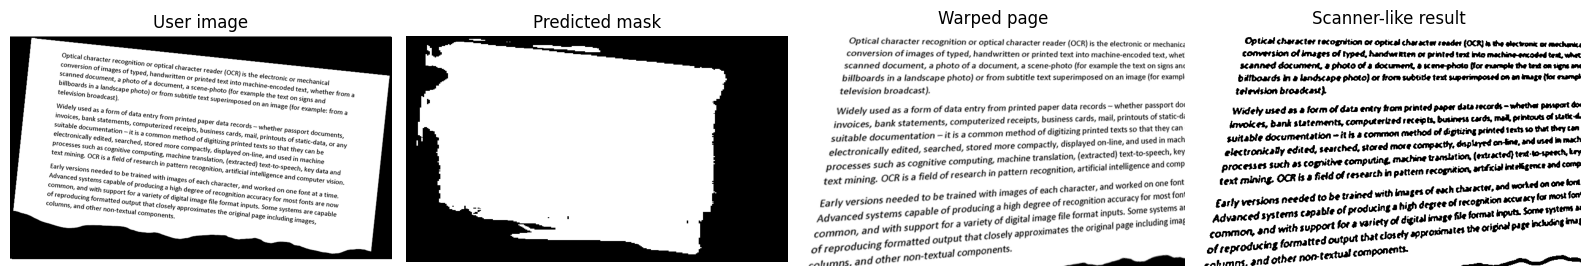

Saved user results inside: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [33]:

USER_IMAGE_PATH = "test3.png"   # change this
user_path = Path(USER_IMAGE_PATH)

if user_path.exists():
    user_image = read_rgb_image(user_path)
    probs_user, mask_small_user, mask_big_user = predict_mask_for_image(best_model, user_image, IMAGE_SIZE)
    contour_user = largest_contour_from_mask(mask_big_user)

    if contour_user is None:
        raise RuntimeError("No document contour found for the user image.")

    quad_user = contour_to_quad(contour_user)
    warped_user, ordered_quad_user = four_point_transform(user_image, quad_user)
    gray_user, scan_user = scanner_enhance(warped_user)

    user_overlay = user_image.copy()
    cv2.polylines(user_overlay, [ordered_quad_user.astype(np.int32)], isClosed=True, color=(0, 255, 0), thickness=6)

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    axes[0].imshow(user_image)
    axes[0].set_title("User image")
    axes[0].axis("off")

    axes[1].imshow(mask_big_user, cmap="gray")
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")

    axes[2].imshow(warped_user)
    axes[2].set_title("Warped page")
    axes[2].axis("off")

    axes[3].imshow(scan_user, cmap="gray")
    axes[3].set_title("Scanner-like result")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    cv2.imwrite(str(OUTPUT_ROOT / "user_overlay.jpg"), cv2.cvtColor(user_overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_warped.jpg"), cv2.cvtColor(warped_user, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_scan.jpg"), scan_user)

    print("Saved user results inside:", OUTPUT_ROOT)
else:
    print("Set USER_IMAGE_PATH to your own image and rerun this cell.")

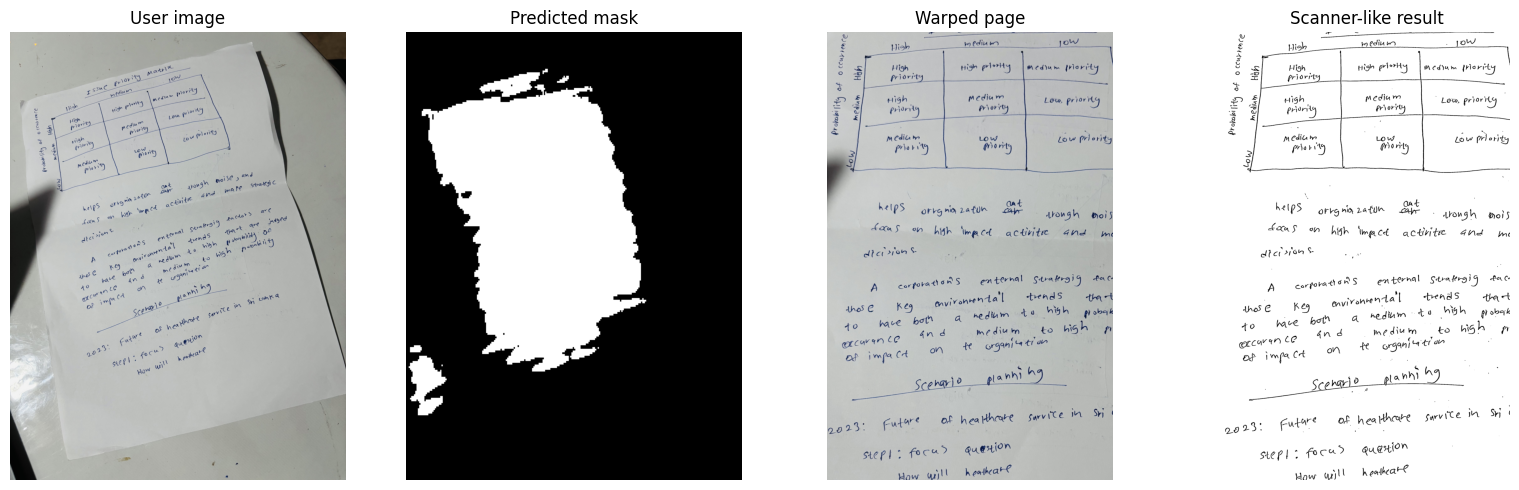

Saved user results inside: /Users/dinura.dissanayake/Desktop/document_scanner_project/outputs


In [34]:

USER_IMAGE_PATH = "Test4.jpeg"   # change this
user_path = Path(USER_IMAGE_PATH)

if user_path.exists():
    user_image = read_rgb_image(user_path)
    probs_user, mask_small_user, mask_big_user = predict_mask_for_image(best_model, user_image, IMAGE_SIZE)
    contour_user = largest_contour_from_mask(mask_big_user)

    if contour_user is None:
        raise RuntimeError("No document contour found for the user image.")

    quad_user = contour_to_quad(contour_user)
    warped_user, ordered_quad_user = four_point_transform(user_image, quad_user)
    gray_user, scan_user = scanner_enhance(warped_user)

    user_overlay = user_image.copy()
    cv2.polylines(user_overlay, [ordered_quad_user.astype(np.int32)], isClosed=True, color=(0, 255, 0), thickness=6)

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    axes[0].imshow(user_image)
    axes[0].set_title("User image")
    axes[0].axis("off")

    axes[1].imshow(mask_big_user, cmap="gray")
    axes[1].set_title("Predicted mask")
    axes[1].axis("off")

    axes[2].imshow(warped_user)
    axes[2].set_title("Warped page")
    axes[2].axis("off")

    axes[3].imshow(scan_user, cmap="gray")
    axes[3].set_title("Scanner-like result")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    cv2.imwrite(str(OUTPUT_ROOT / "user_overlay.jpg"), cv2.cvtColor(user_overlay, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_warped.jpg"), cv2.cvtColor(warped_user, cv2.COLOR_RGB2BGR))
    cv2.imwrite(str(OUTPUT_ROOT / "user_scan.jpg"), scan_user)

    print("Saved user results inside:", OUTPUT_ROOT)
else:
    print("Set USER_IMAGE_PATH to your own image and rerun this cell.")

In [ ]:
z